In [1]:
from LC_utility import *

In [151]:
import cv2
import matplotlib.animation as animation


In [5]:
### Read in Models
lcpath = './data/'
LCm2_i = pd.read_csv(lcpath +'M2_iEtaCarLC.csv')
LCm2_g = pd.read_csv(lcpath +'M2_gEtaCarLC.csv')
LCm2_r = pd.read_csv(lcpath +'M2_rEtaCarLC.csv')
LCm2_z = pd.read_csv(lcpath +'M2_zEtaCarLC.csv')

In [30]:
working_inds_i = np.where(LCm2_i['mJyas2']>0.)[0]
working_inds_g = np.where(LCm2_g['mJyas2']>0.)[0]
working_inds_r = np.where(LCm2_r['mJyas2']>0.)[0]
working_inds_z = np.where(LCm2_z['mJyas2']>0.)[0]

mag_i, mag_err_i = convert_Jy2mag(LCm2_i.loc[working_inds_i,'mJyas2'].values, LCm2_i.loc[working_inds_i,'mJyas2_err'].values)
mag_g, mag_err_g = convert_Jy2mag(LCm2_g.loc[working_inds_g,'mJyas2'].values, LCm2_g.loc[working_inds_g,'mJyas2_err'].values)
mag_r, mag_err_r = convert_Jy2mag(LCm2_r.loc[working_inds_r,'mJyas2'].values, LCm2_r.loc[working_inds_r,'mJyas2_err'].values)
mag_z, mag_err_z = convert_Jy2mag(LCm2_z.loc[working_inds_z,'mJyas2'].values, LCm2_z.loc[working_inds_z,'mJyas2_err'].values)

LCm2_i.loc[working_inds_i,'AB_mag'] = np.array(mag_i)
LCm2_i.loc[working_inds_i,'AB_mag_err'] = np.array(mag_err_i)
LCm2_g.loc[working_inds_g,'AB_mag'] = np.array(mag_g)
LCm2_g.loc[working_inds_g,'AB_mag_err'] = np.array(mag_err_g)
LCm2_r.loc[working_inds_r,'AB_mag'] = np.array(mag_r)
LCm2_r.loc[working_inds_r,'AB_mag_err'] = np.array(mag_err_r)
LCm2_z.loc[working_inds_z,'AB_mag'] = np.array(mag_z)
LCm2_z.loc[working_inds_z,'AB_mag_err'] = np.array(mag_err_z)



In [40]:
LCm2_i

,mjd,mJyas2,mJyas2_err,AB_mag,AB_mag_err
0,53438.236309,8.470009,0.196721,21.580290,0.025216
1,53551.757954,7.672807,0.201869,21.687614,0.028564
2,53709.322149,6.883488,0.303433,21.805479,0.047859
3,53760.297340,5.908279,0.249547,21.971347,0.045856
4,53827.987534,7.323063,0.263127,21.738268,0.039011
...,...,...,...,...,...
393,64042.016000,0.174614,0.262234,25.794804,1.630499
394,64230.472709,0.785830,0.452681,24.161679,0.625423
395,64510.089645,1.102539,0.148120,23.794015,0.145857
396,64648.439366,0.236227,0.250838,25.466675,1.152852


In [50]:
LCm2_z.columns

Index(['mjd', 'mJyas2', 'mJyas2_err', 'AB_mag', 'AB_mag_err'], dtype='object')

In [71]:
t_ran = np.arange(54000, 63500)

i_new = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], k=1))
# i_new_err = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag_err'], k=1))
g_new = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], k=1))
# g_new_err = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag_err'], k=1))

r_new = splev(t_ran, splrep(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag'], k=1))
z_new = splev(t_ran, splrep(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag'], k=1))


In [72]:
t_ran = np.arange(54000, 63500)

i_new_flux = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'mJyas2'], k=1))
# i_new_err = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag_err'], k=1))
g_new_flux = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'mJyas2'], k=1))
# g_new_err = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag_err'], k=1))

r_new_flux = splev(t_ran, splrep(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'mJyas2'], k=1))
z_new_flux = splev(t_ran, splrep(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'mJyas2'], k=1))



In [73]:
def gi2VI(gi):
    VI = (0.675)*(gi)  + (0.364)
    return VI
def vi_to_Theta(vi):
    """
    Convert (V-I) color to Theta [K] = 5040 / .
    
    Reference: Bessell+1998 (approximate polynomial fit).
    Valid for ~0 < V-I < 3.5 (F–M dwarfs).
    """
    vi = np.asarray(vi)

    # value from np.polyfit
    a3, a2, a1, a0 = -0.0192951 ,  0.0197577 ,  0.41923694,  0.53356974
    
    Theta = a0 + a1 * vi + a2 * vi ** 2 + a3 * vi ** 3
    
    return Theta

In [74]:
# Constants
R_sun = 6.957e10       # Solar radius in cm

T_sun = 5772           # Solar effective temperature in K
M_bol_sun = 4.74       # Solar bolometric magnitude

# Example bolometric correction function for i-band
# For simplicity, we use a linear approximation here; replace with real table for accuracy
def BC_i(T_eff):
    # Simple approximation: hotter stars have smaller (more negative) BC
    return 0.1 - 0.0001 * (T_eff - 5772)

def radius_from_Mi_Teff(M_i, T_eff):
    """
    Compute stellar radius in solar radii from i-band magnitude and effective temperature.
    
    Parameters
    ----------
    M_i : float
        Absolute magnitude in i-band
    T_eff : float
        Effective temperature in Kelvin
    
    Returns
    -------
    R : float
        Stellar radius in solar radii
    """
    BC = BC_i(T_eff)
    log_R_Rsun = (M_bol_sun - M_i - BC)/5 - 2*np.log10(T_eff/T_sun)
    R = 10**log_R_Rsun
    
    return R


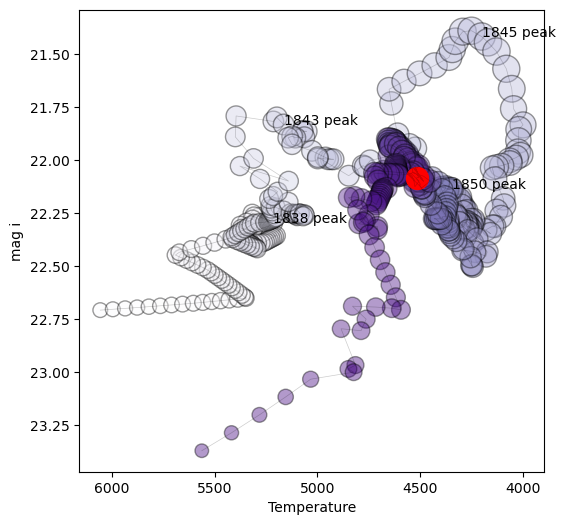

In [106]:
idx = t_ran < 62900

step = 20
color_gi = g_new[idx][::step] - i_new[idx][::step]
mag_i = g_new[idx][::step]
t = t_ran[idx][::step]

T = 5040 / vi_to_Theta(gi2VI(color_gi) )

R_ec = radius_from_Mi_Teff(mag_i-30, T) # 29 come from assume initial radius


fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(1, 1, 1, )

ax.plot(T, mag_i, '-', alpha=.2, c='k', lw=.5)

ax.scatter( T, mag_i , alpha=0.4, s=R_ec/2, edgecolors='black',
            c=t, cmap=plt.cm.Purples, )

ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Temperature');
ax.set_ylabel('mag i')


mjd_peak1 = 54850
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
ax.text(T[idx_peak1], mag_i[idx_peak1], '1838 peak')


mjd_peak1 = 56740
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
ax.text(T[idx_peak1], mag_i[idx_peak1], '1843 peak')

mjd_peak1 = 57430
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
ax.text(T[idx_peak1], mag_i[idx_peak1], '1845 peak')

mjd_peak1 = 59300
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
ax.text(T[idx_peak1], mag_i[idx_peak1], '1850 peak')

nframe = 300
ax.scatter(T[nframe], mag_g[nframe], c='r', s=R_ec[nframe]/2,)



In [288]:
3*400 + 200

1400

In [317]:
t.shape

(445,)

In [323]:
455*2.9 + 180

1499.5

In [ ]:
1499

In [316]:
2.9*170+255

748.0

In [402]:
int(2. * 170 + 490)

830

In [401]:
int(2. * 445 + 490)

1380

In [ ]:
img = get_frame(cap, int(2.9 * nframe + 250) )

In [403]:
def animate(nframe, ):
    """animate the data
     """
    fig.clear()

    img = get_frame(cap, int(2. * nframe + 490) ) #  assume eruption occurs at second peak
    
    #img = get_frame(cap, int(1.6 * nframe + 306) ) # assume eruption occurs at fourth peak
    
    ax1 = fig.add_subplot(gs[0, :] )
    im1 = ax1.imshow(img, #interpolation=None,
                    cmap='gray', origin='upper', alpha=1);
    ax1.axis('off')
    #ax2.grid('off', color='silver', ls='dotted')
    
    # ----------------------------------
    ax2 = fig.add_subplot(gs[1, 0])
    #ax2.plot(t_ran, i_new)
    ax2.plot(t, mag_i)
    
    ax2.axvline(t[nframe], c='r')
    ax2.invert_yaxis()

    #peak1 = 54850
    peak2 = 56740
    #peak3 = 57430
    #peak4 = 59300
    ax2.set_xlabel('time')
    ax2.set_ylabel('mag g')

    for i in range(7):
        c = 'r' if i%3==0 else 'k'
        ax2.axvline(peak2 + 650*i, color=c, ls='--', alpha=0.5, lw=.2)
        ax2.axvline(peak2 - 650*i, color=c, ls='--', alpha=0.5, lw=.2)

    
    #-------------------------------------
    
    ax3 = fig.add_subplot(gs[1, 1] )
    
    
    ax = ax3
    ax.plot(T, mag_i, '-', alpha=.2, c='k', lw=.5)
    
    ax.scatter( T, mag_i , alpha=0.4, s=R_ec/2, edgecolors='black',
                c=t, cmap=plt.cm.Purples, )
    
    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.set_xlabel('Temperature');
    ax.set_ylabel('mag g')

    mjd_peak1 = 54850
    idx_peak1 = np.argmin(np.abs(t - mjd_peak1))
    ax.text(T[idx_peak1], mag_i[idx_peak1], '1838 peak')
    
    
    mjd_peak1 = 56740
    idx_peak1 = np.argmin(np.abs(t - mjd_peak1))
    ax.text(T[idx_peak1], mag_i[idx_peak1], '1843 peak')
    
    mjd_peak1 = 57430
    idx_peak1 = np.argmin(np.abs(t - mjd_peak1))
    ax.text(T[idx_peak1], mag_i[idx_peak1], '1845 peak')
    
    mjd_peak1 = 59300
    idx_peak1 = np.argmin(np.abs(t - mjd_peak1))
    ax.text(T[idx_peak1], mag_i[idx_peak1], '1850 peak')
    
    ax.scatter(T[nframe], mag_g[nframe], c='r', s=R_ec[nframe]/2,)


    print(f'write frame {nframe}')

    #fig.savefig(f'animation/{nframe}.png', dpi=300)

    return fig


In [158]:

video_path = "animation/EtaCar_animation.mp4"

cap = cv2.VideoCapture(video_path)


def get_frame(cap, frame_number=150):
    
    # Set position to the desired frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame", frame_number)
    else:
        print("Got frame", frame_number)
        print("Shape:", frame.shape)
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

#cap.release()

In [159]:
cap.get(cv2.CAP_PROP_FPS), cap.get(cv2.CAP_PROP_FRAME_COUNT)

(29.97002997002997, 1499.0)

In [160]:
import matplotlib.gridspec as gridspec


Got frame 1199
Shape: (360, 640, 3)


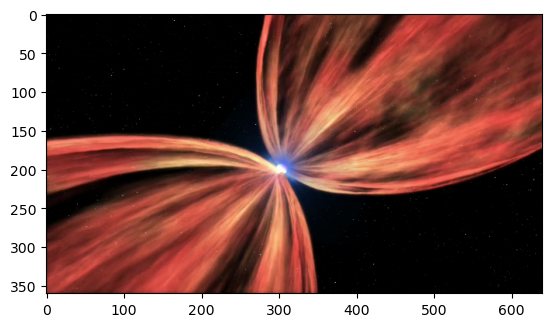

In [376]:
plt.imshow( get_frame(cap, int(40/50 * 1499)) )

In [220]:
int(12/50 * 1499)

359

Got frame 599
Shape: (360, 640, 3)


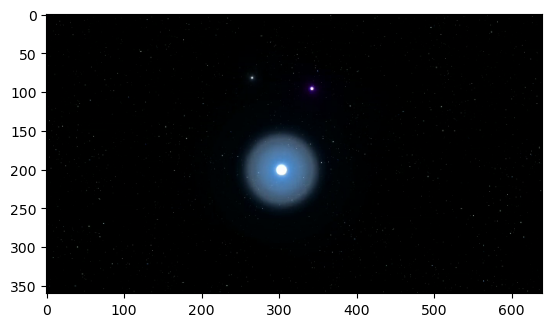

In [273]:
plt.imshow( get_frame(cap, int(20/50 * 1499)) )

In [246]:
12/50 * 1499

359.76

In [293]:
int(34/50 * 1499) #movie peak 2


1019

In [278]:
int(13/50 * 1499)

389

In [208]:
t.shape

(445,)

In [209]:
1499 / 445

3.3685393258426966

In [190]:
839-419

420

In [192]:
170-136

34

In [ ]:
170, 839

In [373]:
np.polyfit(lc_frame, mv_frame,deg=1)

array([  2.08056872, 306.37440758])

In [374]:
2 * 445 + 306

1196

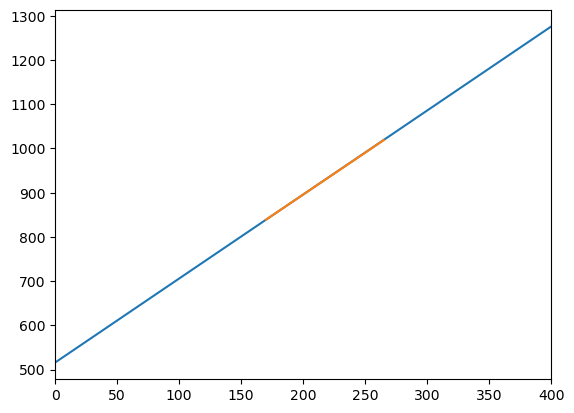

In [329]:

xx = np.linspace(0, 400)
yy = 1.9 * xx + 516
plt.xlim(0, 400)
plt.plot(xx, yy)
plt.plot(lc_frame, mv_frame)


In [256]:
454

454

In [262]:
256, 170, 136, 45

(170, 136, 45)

In [ ]:
 1019, 839

In [357]:
20/50*1499

599.6

In [372]:
lc_frame = [256, 45]
mv_frame = [ 839, 400]           


Got frame 839
Shape: (360, 640, 3)


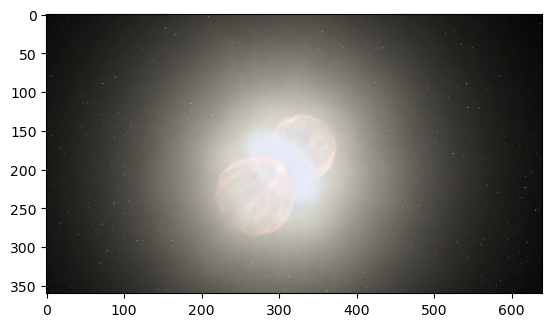

In [371]:
plt.imshow( get_frame(cap, 839) )

Got frame 1194
Shape: (360, 640, 3)
write frame 444


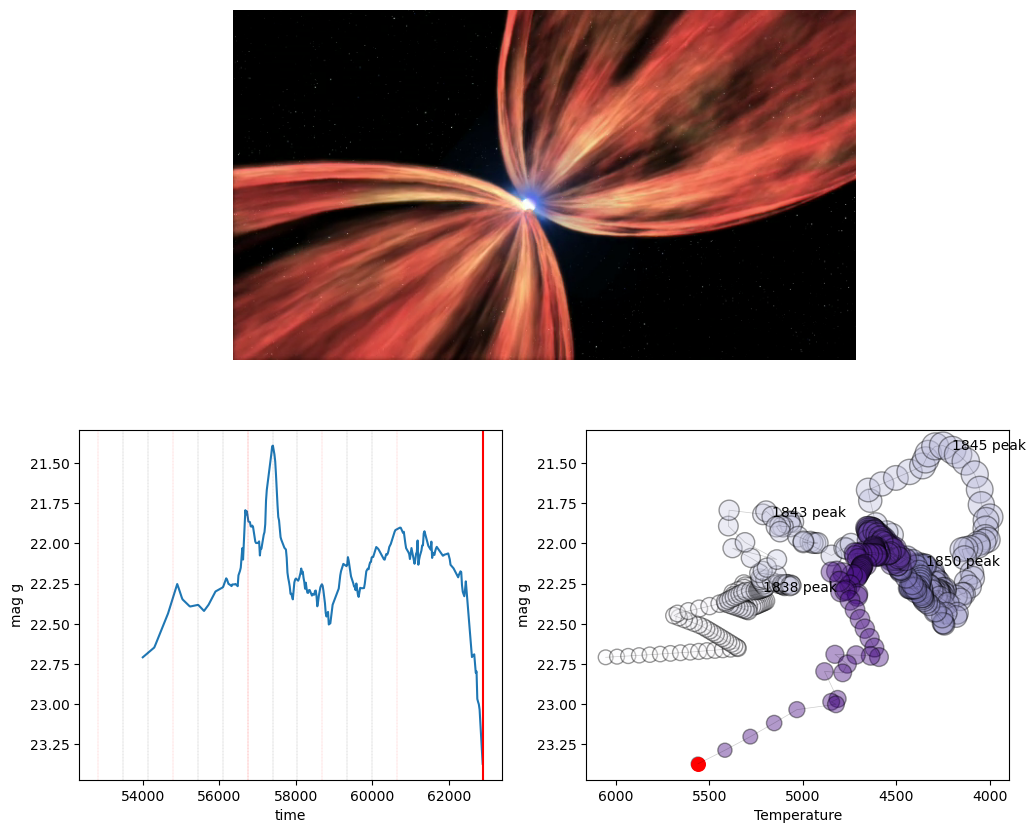

In [389]:
animate(444)

In [155]:
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)


<Figure size 1200x1000 with 0 Axes>

In [405]:
%%time 
anim = animation.FuncAnimation(fig, animate, fargs=(), frames=445 )#interval=100, )   

anim.save('animation/ec_3.mp4', writer=animation.FFMpegWriter(fps=20) )


Got frame 490
Shape: (360, 640, 3)
write frame 0
Got frame 490
Shape: (360, 640, 3)
write frame 0
Got frame 492
Shape: (360, 640, 3)
write frame 1
Got frame 494
Shape: (360, 640, 3)
write frame 2
Got frame 496
Shape: (360, 640, 3)
write frame 3
Got frame 498
Shape: (360, 640, 3)
write frame 4
Got frame 500
Shape: (360, 640, 3)
write frame 5
Got frame 502
Shape: (360, 640, 3)
write frame 6
Got frame 504
Shape: (360, 640, 3)
write frame 7
Got frame 506
Shape: (360, 640, 3)
write frame 8
Got frame 508
Shape: (360, 640, 3)
write frame 9
Got frame 510
Shape: (360, 640, 3)
write frame 10
Got frame 512
Shape: (360, 640, 3)
write frame 11
Got frame 514
Shape: (360, 640, 3)
write frame 12
Got frame 516
Shape: (360, 640, 3)
write frame 13
Got frame 518
Shape: (360, 640, 3)
write frame 14
Got frame 520
Shape: (360, 640, 3)
write frame 15
Got frame 522
Shape: (360, 640, 3)
write frame 16
Got frame 524
Shape: (360, 640, 3)
write frame 17
Got frame 526
Shape: (360, 640, 3)
write frame 18
Got frame 5

### test

Got frame 150
Shape: (360, 640, 3)


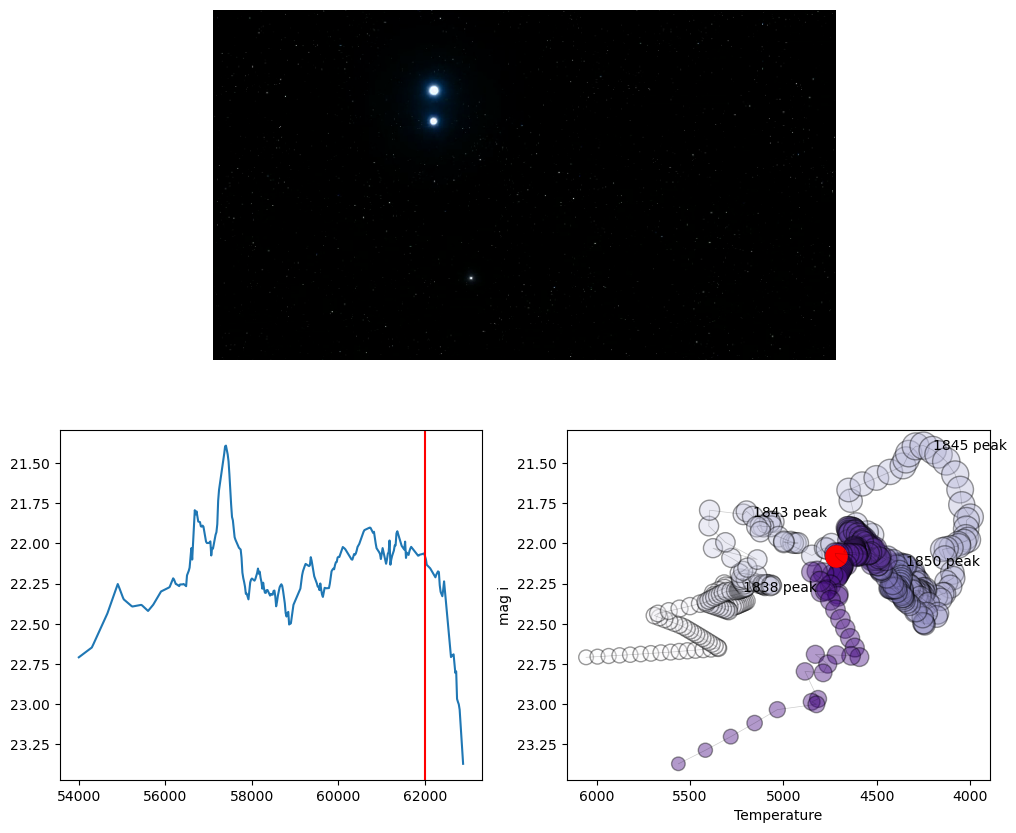

In [129]:
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

img = get_frame(cap, frame_number=150)

nframe = 400

# ----------------------------------

ax1 = fig.add_subplot(gs[0, :] )
im1 = ax1.imshow(img, #interpolation=None,
                cmap='gray', origin='lower', alpha=1);
ax1.axis('off')
#ax2.grid('off', color='silver', ls='dotted')

# ----------------------------------
ax2 = fig.add_subplot(gs[1, 0])
#ax2.plot(t_ran, i_new)
ax2.plot(t, mag_i)

ax2.axvline(t[nframe], c='r')
ax2.invert_yaxis()

#-------------------------------------

ax3 = fig.add_subplot(gs[1, 1] )


ax = ax3
ax.plot(T, mag_i, '-', alpha=.2, c='k', lw=.5)

ax.scatter( T, mag_i , alpha=0.4, s=R_ec/2, edgecolors='black',
            c=t, cmap=plt.cm.Purples, )

ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Temperature');
ax.set_ylabel('mag i')


mjd_peak1 = 54850
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
ax.text(T[idx_peak1], mag_i[idx_peak1], '1838 peak')


mjd_peak1 = 56740
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
ax.text(T[idx_peak1], mag_i[idx_peak1], '1843 peak')

mjd_peak1 = 57430
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
ax.text(T[idx_peak1], mag_i[idx_peak1], '1845 peak')

mjd_peak1 = 59300
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
ax.text(T[idx_peak1], mag_i[idx_peak1], '1850 peak')

ax.scatter(T[nframe], mag_g[nframe], c='r', s=R_ec[nframe]/2,)



29.97002997002997

1499.0

In [ ]:
%%time 
anim = animation.FuncAnimation(fig, animate, fargs=(), frames=len(fits_arr)) #interval=100, )   

anim.save('video.mp4', writer=animation.FFMpegWriter(fps=1) )
